<a href="https://colab.research.google.com/github/tofighi/tutorials/blob/master/AI/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees

Welcome to the Decision Trees module. This notebook is designed for both undergraduate and graduate students and is split into four parts:

* **Part 1: Basic Decision Trees** — Core concepts, terminology, the ID3 algorithm, entropy as the splitting criterion, and a detailed worked example with the classic "Play Tennis" dataset. *No calculus required.*
* **Part 2: Advanced Decision Trees** — Rigorous mathematical treatment of information gain, Gini impurity, MSE for regression trees, gradient descent analogy, and Gradient Boosting as a powerful ensemble extension of decision trees.
* **Part 3: Code for Basic Decision Trees** — Scikit-Learn implementations, tree visualization, and performance evaluation metrics.
* **Part 4: Code for Advanced Decision Trees** — From-scratch NumPy implementations of ID3 and Gradient Boosting; AI problem-solving with decision trees.

---

## Table of Contents
1. **[Part 1: Basic Decision Trees](#part_1)**
   * [1.1 What is a Decision Tree?](#section_1_1)
   * [1.2 A Running Example: Jeeves the Valet (Play Tennis Dataset)](#section_1_2)
   * [1.3 Constructing a Decision Tree Manually](#section_1_3)
   * [1.3a Decision Trees A and B — Visualized](#section_1_3_trees)
   * [1.4 Entropy: Measuring Uncertainty](#section_1_4)
   * [1.5 Information Gain: Choosing the Best Feature](#section_1_5)
   * [1.6 The ID3 Algorithm](#section_1_6)
2. **[Part 2: Advanced Decision Trees & Gradient Boosting](#part_2)**
   * [2.1 Entropy vs. Gini Impurity vs. MSE](#section_2_1)
   * [2.2 From Decision Trees to Gradient Descent](#section_2_2)
   * [2.3 Gradient Boosting: Ensemble of Trees](#section_2_3)
   * [2.4 AI Problem-Solving with Decision Trees](#section_2_4)
3. **[Part 3: Code for Basic Decision Trees](#part_3)**
   * [3.1 Visualizing Entropy & Gini Impurity](#section_3_1)
   * [3.2 Decision Tree Classifier with Scikit-Learn (Play Tennis)](#section_3_2)
   * [3.3 Decision Tree Regressor: Effect of Depth on MSE](#section_3_3)
   * [3.4 Confusion Matrix & Classification Metrics](#section_3_4)
   * [3.5 Matplotlib Implementation of Trees A and B](#section_3_5)
4. **[Part 4: Code for Advanced Decision Trees](#part_4)**
   * [4.1 Implementing the ID3 Algorithm from Scratch](#section_4_1)
   * [4.2 Gradient Boosting from Scratch (MSE Loss)](#section_4_2)
   * [4.3 AI Problem-Solving with Decision Trees: Student Policy Agent](#section_4_3)


<a name="part_1"></a>
# Part 1: Basic Decision Trees

This section covers the fundamental building blocks of decision trees using intuitive concepts and simple examples. **No calculus or matrix derivations are needed here** — those are covered in Part 2.

---

<a name="section_1_1"></a>
### 1.1 What is a Decision Tree?

A **Decision Tree** is one of the simplest yet most powerful forms of machine learning. It takes as input a **vector of feature values** and returns a single output value by asking a sequence of questions (tests) about the features.

#### Structure of a Decision Tree
- **Internal (Decision) Nodes** — Each node tests one input feature and branches based on the feature's value.
- **Branches (Arcs)** — Each branch is labeled with a value of the feature being tested.
- **Leaf Nodes** — Each leaf specifies a final output value (a class label for classification, or a number for regression).

#### Advantages
- **Interpretable:** The tree is easily understood by humans ("white-box" model).
- **No feature scaling required:** Works directly on raw data.
- **Handles mixed data:** Can handle both numerical and categorical features.
- **Performs well on small datasets.**

#### Disadvantages
- **Greedy heuristic:** Learning the optimal tree is NP-complete, so greedy algorithms are used in practice.
- **Overfitting:** Can create over-complex trees that do not generalize well.
- **Instability:** Small variations in data can produce very different trees.
- **Limited expressiveness:** May not represent some complex functions well.

> **Key Idea:** Every decision tree corresponds to a propositional logic formula. For $n$ binary features, there are $2^{2^n}$ possible distinct Boolean functions — an astronomically large hypothesis space!


<a name="section_1_2"></a>
### 1.2 A Running Example: Jeeves the Valet (Play Tennis Dataset)

We will use the classic **Play Tennis** example throughout Part 1. Jeeves wants to predict whether Bertie will play tennis on a given day based on weather features.

#### Training Set (14 days of observations)

| Day | Outlook  | Temp | Humidity | Wind   | Play Tennis? |
|-----|----------|------|----------|--------|--------------|
| 1   | Sunny    | Hot  | High     | Weak   | No           |
| 2   | Sunny    | Hot  | High     | Strong | No           |
| 3   | Overcast | Hot  | High     | Weak   | **Yes**      |
| 4   | Rain     | Mild | High     | Weak   | **Yes**      |
| 5   | Rain     | Cool | Normal   | Weak   | **Yes**      |
| 6   | Rain     | Cool | Normal   | Strong | No           |
| 7   | Overcast | Cool | Normal   | Strong | **Yes**      |
| 8   | Sunny    | Mild | High     | Weak   | No           |
| 9   | Sunny    | Cool | Normal   | Weak   | **Yes**      |
| 10  | Rain     | Mild | Normal   | Weak   | **Yes**      |
| 11  | Sunny    | Mild | Normal   | Strong | **Yes**      |
| 12  | Overcast | Mild | High     | Strong | **Yes**      |
| 13  | Overcast | Hot  | Normal   | Weak   | **Yes**      |
| 14  | Rain     | Mild | High     | Strong | No           |

- **Positive examples (+):** Days 3, 4, 5, 7, 9, 10, 11, 12, 13 → **9 examples**
- **Negative examples (−):** Days 1, 2, 6, 8, 14 → **5 examples**

**Features:** Outlook (Sunny/Overcast/Rain), Temp (Hot/Mild/Cool), Humidity (High/Normal), Wind (Weak/Strong)

**Target:** Play Tennis? (Yes/No) — a **binary classification** problem.


### The Test Set

To evaluate our decision tree later, we will use a separate test set of 14 new days:

| Day | Outlook | Temp | Humidity | Wind | Play Tennis? |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | Sunny | Mild | High | Strong | **No** |
| 2 | Rain | Hot | Normal | Strong | **No** |
| 3 | Rain | Cool | High | Strong | **No** |
| 4 | Overcast | Hot | High | Strong | **Yes** |
| 5 | Overcast | Cool | Normal | Weak | **Yes** |
| 6 | Rain | Hot | High | Weak | **Yes** |
| 7 | Overcast | Mild | Normal | Weak | **Yes** |
| 8 | Overcast | Cool | High | Weak | **Yes** |
| 9 | Rain | Cool | High | Weak | **Yes** |
| 10 | Rain | Mild | Normal | Strong | **No** |
| 11 | Overcast | Mild | High | Weak | **Yes** |
| 12 | Sunny | Mild | Normal | Weak | **Yes** |
| 13 | Sunny | Cool | High | Strong | **No** |
| 14 | Sunny | Cool | High | Weak | **No** |


<a name="section_1_3"></a>
### 1.3 Constructing a Decision Tree Manually

Consider two different trees built from the same training data:

**Tree 1 (Simple — Test Outlook first):**
```
Outlook
├── Sunny   → test Humidity
│            ├── Normal → YES
│            └── High   → NO
├── Overcast → YES  (all overcast days: Bertie always plays)
└── Rain     → test Wind
              ├── Weak   → YES
              └── Strong → NO
```
This tree corresponds to the logical formula:
$$\text{(Outlook=Sunny} \wedge \text{Humidity=Normal)} \vee \text{(Outlook=Overcast)} \vee \text{(Outlook=Rain} \wedge \text{Wind=Weak)} \tag{1.1}$$

**Tree 2 (Complex — Test Temperature first):** Produces a much deeper tree.

**Comparing on the Test Set:**
- Tree 1 (simple): Classifies **14/14** test examples correctly
- Tree 2 (complex): Classifies **7/14** test examples correctly

> **Key Insight:** The simpler tree generalizes better. The complex tree likely **overfits** to the training examples. This motivates us to prefer smaller, shallower trees — a principle known as **Occam's Razor**.

**How do we systematically find the best feature to test?** → We need a principled measure: **Entropy and Information Gain**.


<a name="section_1_3_trees"></a>
### 1.3a Decision Trees A and B — Visualized

Consider **Decision Tree (A)** and **Decision Tree (B)** from the Play Tennis dataset. Both trees classify all 14 training examples perfectly — yet they behave very differently on the test set:

| Tree | Root Feature | Test Accuracy | Depth | Notes |
|------|-------------|--------------|-------|-------|
| **A** | Outlook | **14/14 = 100%** | 2 | Simple, generalizes well |
| **B** | Temperature | 7/14 = 50% | 4 | Complex, **overfits** |

Tree B also illustrates the **"no examples left"** base case: the node marked **?** (Hot, High Humidity, Rain) never appeared in training — so the tree has no data to decide with.

> **Note on Implementation:** The Python code using Matplotlib to programmatically draw and visualize these specific trees is provided in **[Part 3 (Section 3.5)](#section_3_5)**.

<a name="section_1_4"></a>
### 1.4 Entropy: Measuring Uncertainty

To choose the **most important feature** at each step, we measure how much each feature reduces our **uncertainty** about the output. The mathematical tool is **Entropy** from Information Theory.

#### Definition
Given a probability distribution $P(c_1), \ldots, P(c_k)$ over $k$ outcomes, the **Shannon entropy** is:

$$\boxed{H = I(P(c_1), \ldots, P(c_k)) = -\sum_{i=1}^{k} P(c_i) \log_2 P(c_i)} \tag{1.2}$$

For **binary classification** with $p$ positive and $n$ negative examples:

$$\boxed{I\!\left(\frac{p}{p+n},\, \frac{n}{p+n}\right) = -\frac{p}{p+n}\log_2\!\frac{p}{p+n} - \frac{n}{p+n}\log_2\!\frac{n}{p+n}} \tag{1.3}$$

#### Key Properties of Entropy:
| Distribution | Entropy | Meaning |
|---|---|---|
| $(0.5, 0.5)$ | $H = 1.0$ bit | Maximum uncertainty — complete ambiguity |
| $(0.99, 0.01)$ | $H \approx 0.08$ bits | Very low uncertainty — almost certain |
| $(1.0, 0.0)$ | $H = 0$ bits | Zero uncertainty — perfectly pure node |

> **Intuition:** High entropy = mixed labels = impure node. Low entropy = mostly one class = pure node. We want splits that **reduce entropy as much as possible**.

#### Entropy Before Splitting (Play Tennis dataset)
With $p = 9$ positive and $n = 5$ negative examples:

$$I\!\left(\frac{9}{14}, \frac{5}{14}\right) = -\frac{9}{14}\log_2\frac{9}{14} - \frac{5}{14}\log_2\frac{5}{14} \approx \mathbf{0.940 \text{ bits}} \tag{1.4}$$


<a name="section_1_5"></a>
### 1.5 Information Gain: Choosing the Best Feature

The **Information Gain** of a feature $A$ is the reduction in entropy when we test feature $A$. If feature $A$ splits examples into $k$ subsets (one per value of $A$), with $p_i$ positive and $n_i$ negative examples in subset $i$:

$$\boxed{\text{Gain}(A) = I\!\left(\frac{p}{p+n}, \frac{n}{p+n}\right) - \sum_{i=1}^{k} \frac{p_i + n_i}{p+n} \cdot I\!\left(\frac{p_i}{p_i+n_i}, \frac{n_i}{p_i+n_i}\right)} \tag{1.5}$$

**We always choose the feature with the largest information gain.**

#### Worked Example: Calculating Gain(Outlook)

Splitting on Outlook gives three subsets:
- **Sunny:** Days 1,2,8,9,11 → $p_1=2$, $n_1=3$: $I(2/5, 3/5) = 0.971$ bits
- **Overcast:** Days 3,7,12,13 → $p_2=4$, $n_2=0$: $I(4/4, 0) = 0$ bits (perfectly pure!)
- **Rain:** Days 4,5,6,10,14 → $p_3=3$, $n_3=2$: $I(3/5, 2/5) = 0.971$ bits

$$\text{Gain(Outlook)} = 0.940 - \left(\frac{5}{14} \cdot 0.971 + \frac{4}{14} \cdot 0 + \frac{5}{14} \cdot 0.971\right) = 0.940 - 0.694 = \mathbf{0.247} \tag{1.6}$$

#### Summary of All Feature Gains

| Feature    | Information Gain |
|------------|------------------|
| **Outlook**    | **0.247** ← Highest! |
| Humidity   | 0.151 |
| Wind       | 0.048 |
| Temp       | 0.029 |

> **Conclusion:** We test **Outlook** at the root node.

After recursing:
- **Outlook = Overcast** → All positive → Leaf: **YES**
- **Outlook = Sunny** → Best next feature: **Humidity** (Gain = 0.971)
  - Humidity = Normal → **YES** | Humidity = High → **NO**
- **Outlook = Rain** → Best next feature: **Wind** (Gain = 0.971)
  - Wind = Weak → **YES** | Wind = Strong → **NO**


<a name="section_1_6"></a>
### 1.6 The ID3 Algorithm

The **ID3 (Iterative Dichotomiser 3)** algorithm builds a decision tree using information gain as the feature selection criterion.

#### Algorithm (Pseudocode)

```
ID3(Features, Examples):
  1. If ALL examples are POSITIVE  → return Leaf(YES)
  2. If ALL examples are NEGATIVE  → return Leaf(NO)
  3. If NO FEATURES LEFT           → return Leaf(majority class)
  4. If NO EXAMPLES LEFT           → return Leaf(majority class of parent)
  5. ELSE:
       f ← feature with maximum Information Gain
       For each value v of feature f:
           Add branch labeled v
           Add subtree: ID3(Features - {f}, {examples where f = v})
```

#### Base Cases

**"No features left":** Occurs when data is **noisy** — the same feature values appear with different labels (e.g., same weather on two days, different decision). Predict the **majority class**.

**"No examples left":** Occurs when a combination of feature values never appeared in training. Use the majority class from the **parent node**.

#### Why Greedy?

The optimal decision tree is NP-complete to find. With $n = 10$ binary features, there are $2^{2^{10}} \approx 10^{308}$ possible Boolean functions — impossible to search exhaustively! ID3 uses a **greedy divide-and-conquer** approach, hoping locally optimal splits lead to a globally good tree.


<a name="part_2"></a>
# Part 2: Advanced Decision Trees & Gradient Boosting

> **[ADVANCED CONTENT]**
>
> This section contains formal mathematical derivations and advanced ensemble methods. Familiarity with logarithms, basic calculus, and optimization is recommended.

---

<a name="section_2_1"></a>
### 2.1 Splitting Criteria: Entropy vs. Gini Impurity vs. MSE

There are three main impurity/loss measures used in decision trees, depending on whether the task is classification or regression.

#### A. Entropy (Information Gain) — Classification

As introduced in Part 1, for a node $S$ with $K$ classes:

$$\boxed{H(S) = -\sum_{k=1}^{K} p_k \log_2 p_k} \tag{2.1}$$

where $p_k$ is the fraction of examples in node $S$ belonging to class $k$.

**Information Gain** when splitting on feature $A$ with values $\{v_1, \ldots, v_m\}$:

$$\text{Gain}(S, A) = H(S) - \sum_{i=1}^{m} \frac{|S_i|}{|S|} H(S_i) \tag{2.2}$$

#### B. Gini Impurity — Classification (CART algorithm)

$$\boxed{G(S) = 1 - \sum_{k=1}^{K} p_k^2} \tag{2.3}$$

- $G = 0$: Perfectly pure node (only one class)
- $G = 0.5$: Maximum impurity for binary classification (equal mix)

**Gini Gain** when splitting on feature $A$:

$$\text{Gini Gain}(S, A) = G(S) - \sum_{i=1}^{m} \frac{|S_i|}{|S|} G(S_i) \tag{2.4}$$

| Property | Entropy (ID3, C4.5) | Gini (CART) |
|---|---|---|
| Range | $[0, \log_2 K]$ | $[0, 1 - 1/K]$ |
| Computation | Slower (log) | Faster (no log) |
| Used by | ID3, C4.5, CHAID | scikit-learn (default) |

#### C. Mean Squared Error (MSE) — Regression Trees

For **regression trees** where the target $y$ is continuous:

$$\boxed{\text{MSE}(S) = \frac{1}{|S|} \sum_{i \in S} (y^{(i)} - \bar{y}_S)^2} \tag{2.5}$$

where $\bar{y}_S = \frac{1}{|S|}\sum_{i \in S} y^{(i)}$ is the mean of the target values in node $S$. The leaf prediction is also $\bar{y}_S$.

**Variance Reduction** when splitting on feature $A$:

$$\text{VarRed}(S, A) = \text{MSE}(S) - \sum_{i=1}^{m} \frac{|S_i|}{|S|} \cdot \text{MSE}(S_i) \tag{2.6}$$


<a name="section_2_2"></a>
### 2.2 From Decision Trees to Gradient Descent

Although decision trees are typically built using greedy splitting, there is a profound connection between **gradient boosting** and gradient descent that unifies tree-based and gradient-based machine learning.

#### The Decision Tree as a Functional

A trained decision tree $f(x; \Theta)$ with parameters $\Theta$ (split rules and leaf values) defines a piecewise-constant function. The loss over all $m$ training examples is:

$$\mathcal{L}(\Theta) = \frac{1}{m} \sum_{i=1}^{m} L(y^{(i)}, f(x^{(i)}; \Theta)) \tag{2.7}$$

- For **regression** (MSE loss): $L(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2$
- For **binary classification** (cross-entropy): $L(y, p) = -y\log p - (1-y)\log(1-p)$

#### Why Can't We Use Standard Gradient Descent on a Tree?

The structure of a decision tree — which feature to split on, which threshold to use — is **discrete**. There is no smooth gradient to follow. Instead, at each node we perform a **greedy search** over all possible splits. This is effectively a **local** optimization step.

#### The Gradient Descent Analogy

| Standard Gradient Descent | Gradient Boosting |
|---|---|
| Update parameters: $\theta := \theta - \alpha \nabla_\theta \mathcal{L}$ | Update function: $F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$ |
| $\nabla_\theta \mathcal{L}$ = gradient of loss w.r.t. parameters | $h_t$ = tree fitted to **negative gradient** of loss |
| Step size $\alpha$ (learning rate) | Step size $\eta$ (learning rate) |
| Operates in **parameter space** | Operates in **function space** |

In gradient boosting, instead of updating parameters we add a new function (tree) that **points in the direction that reduces loss most** — this is "steepest descent in function space".


<a name="section_2_3"></a>
### 2.3 Gradient Boosting: Ensemble of Trees

**Gradient Boosting** builds an additive ensemble of weak learners (usually shallow decision trees) stage-by-stage, where each new tree corrects the errors of the previous ensemble.

#### The Algorithm

**Input:** Training data $\{(x^{(i)}, y^{(i)})\}_{i=1}^m$, loss $L$, number of trees $T$, learning rate $\eta$

**Step 1 — Initialize** with a constant that minimizes loss:
$$F_0(x) = \arg\min_\gamma \sum_{i=1}^m L(y^{(i)}, \gamma) \tag{2.8}$$
For MSE loss: $F_0 = \bar{y}$ (the mean of all targets).

**Step 2 — For** $t = 1, 2, \ldots, T$:

**(a) Compute pseudo-residuals** (negative gradient of loss w.r.t. current predictions):
$$r_t^{(i)} = -\frac{\partial L(y^{(i)}, F_{t-1}(x^{(i)}))}{\partial F_{t-1}(x^{(i)})} \tag{2.9}$$
For MSE: $r_t^{(i)} = y^{(i)} - F_{t-1}(x^{(i)})$ (the ordinary residuals!)

**(b) Fit a regression tree** $h_t$ to the pseudo-residuals $\{(x^{(i)}, r_t^{(i)})\}$.

**(c) Update the ensemble:**
$$F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x) \tag{2.10}$$

**Step 3 — Final prediction:** $\hat{y} = F_T(x)$

#### Pseudo-Residuals for Different Loss Functions

| Loss Function | Pseudo-residual $r_t^{(i)}$ |
|---|---|
| MSE: $\frac{1}{2}(y - \hat{y})^2$ | $r = y - \hat{y}$ (true residual) |
| MAE: $|y - \hat{y}|$ | $r = \text{sign}(y - \hat{y})$ |
| Log-loss (classification) | $r = y - p$ (where $p$ is predicted probability) |

#### Key Hyperparameters

| Parameter | Effect |
|---|---|
| $T$ (`n_estimators`) | More trees → lower training error; risk of overfitting |
| $\eta$ (`learning_rate`) | Smaller $\eta$ → slower but better generalization |
| `max_depth` | Controls tree complexity; shallow trees are weak learners |
| `subsample` | Stochastic boosting — fit each tree on a random subset |


<a name="section_2_4"></a>
### 2.4 AI Problem-Solving with Decision Trees

Decision trees are not just classifiers — they are general-purpose **problem-solving tools** in AI.

#### A. Hypothesis Space Search

A decision tree learning algorithm searches through an **exponentially large** hypothesis space. With $n$ binary features, there are $2^{2^n}$ possible Boolean functions. ID3 navigates this space using a **greedy hill-climbing strategy** guided by information gain:

- **Preference bias (Occam's Razor):** ID3 prefers shorter, simpler trees.
- **Restriction bias:** ID3 only searches trees consistent with training data.
- This is contrasted with models like SVMs that have hard restriction biases.

#### B. Inductive Learning & Overfitting

From training examples, a decision tree **generalizes** to unseen inputs. The key challenge is **overfitting**:

- A tree that memorizes training data perfectly may fail on new data.
- **Pruning** strategies help generalize:
  - *Pre-pruning:* Stop splitting when gain is below a threshold.
  - *Post-pruning:* Grow full tree, then prune branches that don't improve validation accuracy.
- The **bias-variance tradeoff** applies: deeper trees = lower bias, higher variance.

#### C. Decision Trees as AI Agent Policies

The original AI motivation: *Jeeves the valet as a rational agent* — observing the world (weather features) and choosing actions (predict whether to lay out tennis gear).

In AI, decision trees can represent:
- **Policy functions** in reinforcement learning (map state → action)
- **Knowledge bases** (symbolic representation of expert domain rules)
- **Utility functions** for rational agents

#### D. Formal Comparison of Impurity Measures (Binary Case)

For binary classification with positive class probability $p$:

$$H(p) = -p\log_2 p - (1-p)\log_2(1-p) \tag{2.11}$$
$$G(p) = 2p(1-p) \tag{2.12}$$

Both measures are: **symmetric** around $p=0.5$, **zero** at $p \in \{0,1\}$ (pure nodes), **maximized** at $p=0.5$, and **concave** functions of $p$.


<a name="part_3"></a>
# Part 3: Code for Basic Decision Trees

This section implements decision trees using **Scikit-Learn** and visualizes key concepts from Part 1 — entropy, information gain, and tree structure.

---

<a name="section_3_1"></a>
### 3.1 Visualizing Entropy, Gini Impurity, and Information Gain


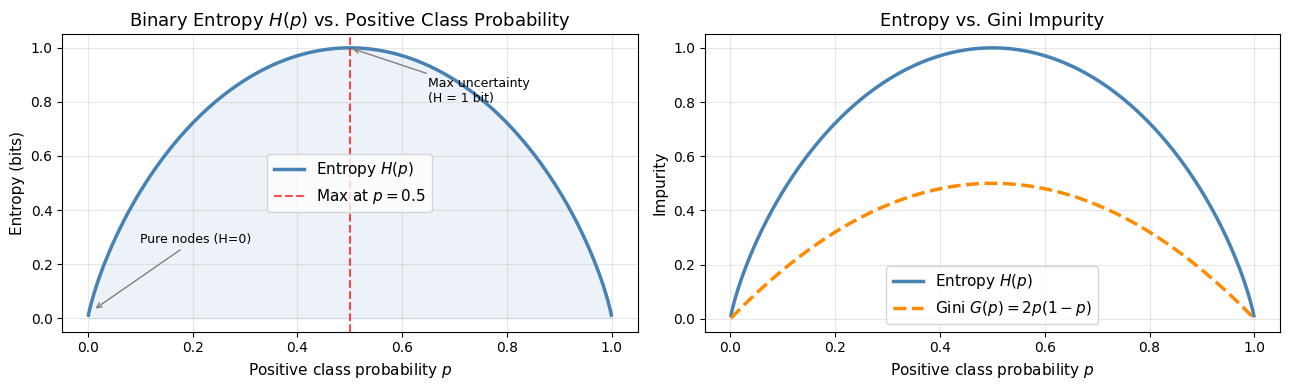

=== Entropy Calculations for Play Tennis Dataset ===
Initial entropy I(9/14, 5/14) = 0.9403 bits
Entropy(Sunny)    I(2/5, 3/5) = 0.9710 bits
Entropy(Overcast) I(4/4, 0/4) = 0.0000 bits  (pure!)
Entropy(Rain)     I(3/5, 2/5) = 0.9710 bits

=== Information Gain for Each Feature ===
  Gain(Outlook   ) = 0.2467  <- BEST SPLIT!
  Gain(Humidity  ) = 0.1518
  Gain(Wind      ) = 0.0481
  Gain(Temp      ) = 0.0292


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Entropy for binary classification ────────────────────────────────────────
def entropy(p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# ── Gini Impurity (binary case) ────────────────────────────────────────────
def gini(p):
    return 2 * p * (1 - p)

# ── Plot both impurity measures side by side ──────────────────────────────────
p_vals = np.linspace(0.001, 0.999, 500)
H = entropy(p_vals)
G = gini(p_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Entropy plot
axes[0].plot(p_vals, H, color='steelblue', linewidth=2.5, label='Entropy $H(p)$')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Max at $p=0.5$')
axes[0].fill_between(p_vals, H, alpha=0.1, color='steelblue')
axes[0].set_title('Binary Entropy $H(p)$ vs. Positive Class Probability', fontsize=13)
axes[0].set_xlabel('Positive class probability $p$', fontsize=11)
axes[0].set_ylabel('Entropy (bits)', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Max uncertainty\n(H = 1 bit)', xy=(0.5, 1.0), xytext=(0.65, 0.80),
                 fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))
axes[0].annotate('Pure nodes (H=0)', xy=(0.01, 0.03), xytext=(0.10, 0.28),
                 fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))

# Entropy vs. Gini comparison
axes[1].plot(p_vals, H, color='steelblue', linewidth=2.5, label='Entropy $H(p)$')
axes[1].plot(p_vals, G, color='darkorange', linewidth=2.5,
             label='Gini $G(p) = 2p(1-p)$', linestyle='--')
axes[1].set_title('Entropy vs. Gini Impurity', fontsize=13)
axes[1].set_xlabel('Positive class probability $p$', fontsize=11)
axes[1].set_ylabel('Impurity', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Numerical check from the Jeeves example ──────────────────────────────────
print('=== Entropy Calculations for Play Tennis Dataset ===')
print(f'Initial entropy I(9/14, 5/14) = {entropy(9/14):.4f} bits')
print(f'Entropy(Sunny)    I(2/5, 3/5) = {entropy(2/5):.4f} bits')
print(f'Entropy(Overcast) I(4/4, 0/4) = 0.0000 bits  (pure!)')
print(f'Entropy(Rain)     I(3/5, 2/5) = {entropy(3/5):.4f} bits')

gain_outlook  = entropy(9/14) - (5/14*entropy(2/5) + 4/14*0 + 5/14*entropy(3/5))
gain_humidity = entropy(9/14) - (7/14*entropy(6/7) + 7/14*entropy(3/7))
gain_wind     = entropy(9/14) - (8/14*entropy(6/8) + 6/14*entropy(3/6))
gain_temp     = entropy(9/14) - (4/14*entropy(3/4) + 6/14*entropy(4/6) + 4/14*entropy(2/4))

print('\n=== Information Gain for Each Feature ===')
for feat, gain in [('Outlook', gain_outlook), ('Humidity', gain_humidity),
                    ('Wind', gain_wind), ('Temp', gain_temp)]:
    best = '  <- BEST SPLIT!' if feat == 'Outlook' else ''
    print(f'  Gain({feat:<10}) = {gain:.4f}{best}')


<a name="section_3_2"></a>
### 3.2 Decision Tree Classifier with Scikit-Learn (Play Tennis Dataset)

We encode the Play Tennis dataset and train a `DecisionTreeClassifier` using Scikit-Learn with entropy as the splitting criterion.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# ── Dataset ───────────────────────────────────────────────────────────────────
data = {
    'Outlook':  ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
                 'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temp':     ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                 'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal',
                 'High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':     ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
                 'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis':['No','No','Yes','Yes','Yes','No','Yes',
                  'No','Yes','Yes','Yes','Yes','Yes','No']
}
df = pd.DataFrame(data)
print('Play Tennis Dataset:')
print(df.to_string(index=False))

# ── Encode categorical features ───────────────────────────────────────────────
le_dict = {}
df_enc = df.copy()
for col in df.columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    le_dict[col] = le

X = df_enc[['Outlook', 'Temp', 'Humidity', 'Wind']].values
y = df_enc['PlayTennis'].values

# ── Train Decision Tree ───────────────────────────────────────────────────────
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

feature_names = ['Outlook', 'Temp', 'Humidity', 'Wind']
print('\n=== Decision Tree Structure (text) ===')
print(export_text(clf, feature_names=feature_names))
print(f'Training Accuracy: {accuracy_score(y, clf.predict(X)):.4f}')


Play Tennis Dataset:
 Outlook Temp Humidity   Wind PlayTennis
   Sunny  Hot     High   Weak         No
   Sunny  Hot     High Strong         No
Overcast  Hot     High   Weak        Yes
    Rain Mild     High   Weak        Yes
    Rain Cool   Normal   Weak        Yes
    Rain Cool   Normal Strong         No
Overcast Cool   Normal Strong        Yes
   Sunny Mild     High   Weak         No
   Sunny Cool   Normal   Weak        Yes
    Rain Mild   Normal   Weak        Yes
   Sunny Mild   Normal Strong        Yes
Overcast Mild     High Strong        Yes
Overcast  Hot   Normal   Weak        Yes
    Rain Mild     High Strong         No

=== Decision Tree Structure (text) ===
|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Outlook <= 1.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Wind >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Outlook >  1.50
|   |   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   

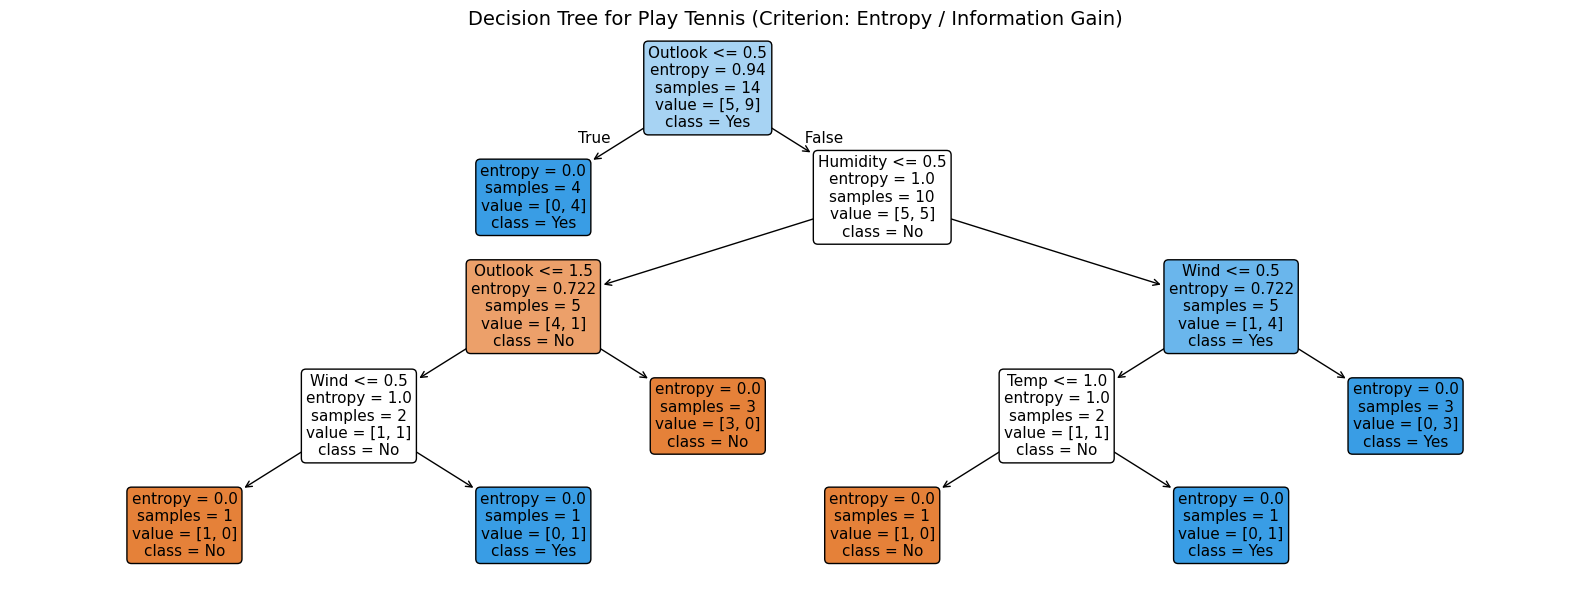

In [3]:
# ── Visualize the learned tree ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    clf,
    feature_names=['Outlook', 'Temp', 'Humidity', 'Wind'],
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('Decision Tree for Play Tennis (Criterion: Entropy / Information Gain)',
             fontsize=14)
plt.tight_layout()
plt.show()


<a name="section_3_3"></a>
### 3.3 Decision Tree Regressor: Effect of Depth on MSE

Decision trees can also solve **regression** problems. Here we apply a Regression Tree to a synthetic nonlinear dataset and show how tree depth controls the bias-variance tradeoff.


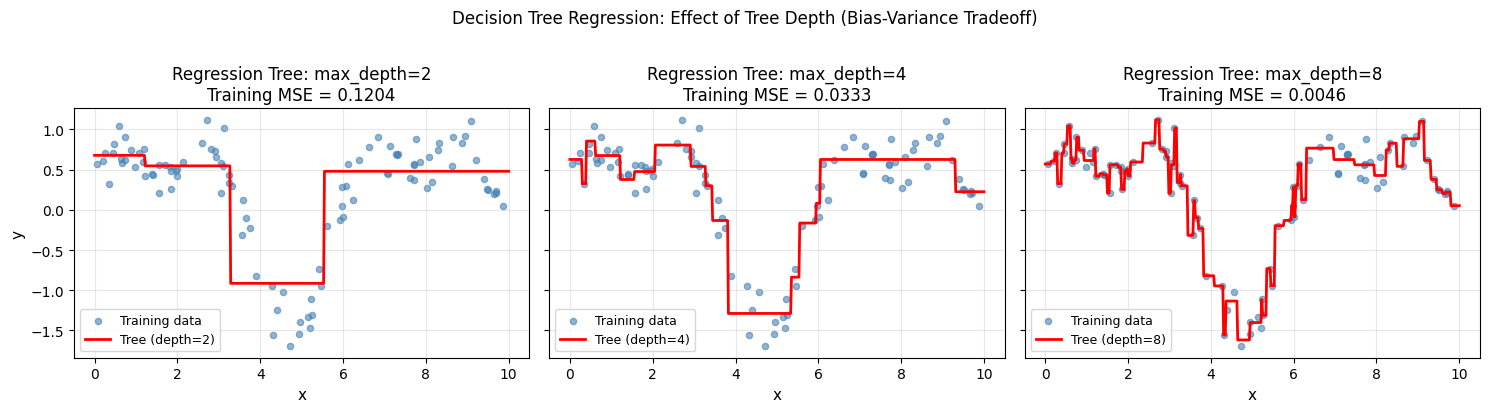

Shallow trees: high bias (underfit). Deep trees: high variance (overfit).
MSE (Eq. 2.5) is the splitting criterion for regression trees.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# ── Generate synthetic 1D regression data ────────────────────────────────────
np.random.seed(42)
X_reg = np.sort(np.random.uniform(0, 10, 100)).reshape(-1, 1)
y_reg = np.sin(X_reg.ravel()) + 0.5 * np.cos(2 * X_reg.ravel()) + np.random.normal(0, 0.2, 100)

# ── Fit trees of different depths ────────────────────────────────────────────
depths = [2, 4, 8]
X_test = np.linspace(0, 10, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, depth in zip(axes, depths):
    reg = DecisionTreeRegressor(max_depth=depth, criterion='squared_error', random_state=42)
    reg.fit(X_reg, y_reg)
    y_pred_reg = reg.predict(X_test)
    train_mse = np.mean((reg.predict(X_reg) - y_reg)**2)

    ax.scatter(X_reg, y_reg, s=20, alpha=0.6, color='steelblue', label='Training data')
    ax.plot(X_test, y_pred_reg, color='red', linewidth=2, label=f'Tree (depth={depth})')
    ax.set_title(f'Regression Tree: max_depth={depth}\nTraining MSE = {train_mse:.4f}',
                 fontsize=12)
    ax.set_xlabel('x', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel('y', fontsize=11)
plt.suptitle('Decision Tree Regression: Effect of Tree Depth (Bias-Variance Tradeoff)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Shallow trees: high bias (underfit). Deep trees: high variance (overfit).')
print('MSE (Eq. 2.5) is the splitting criterion for regression trees.')


<a name="section_3_4"></a>
### 3.4 Confusion Matrix & Classification Metrics

For classification tasks, accuracy alone doesn't tell the full story. We evaluate with precision, recall, F1-score, and the confusion matrix on a larger synthetic dataset.


  Metric                    Value
  Accuracy                 0.8444
  Precision                0.9737
  Recall                   0.7400
  F1 Score                 0.8409


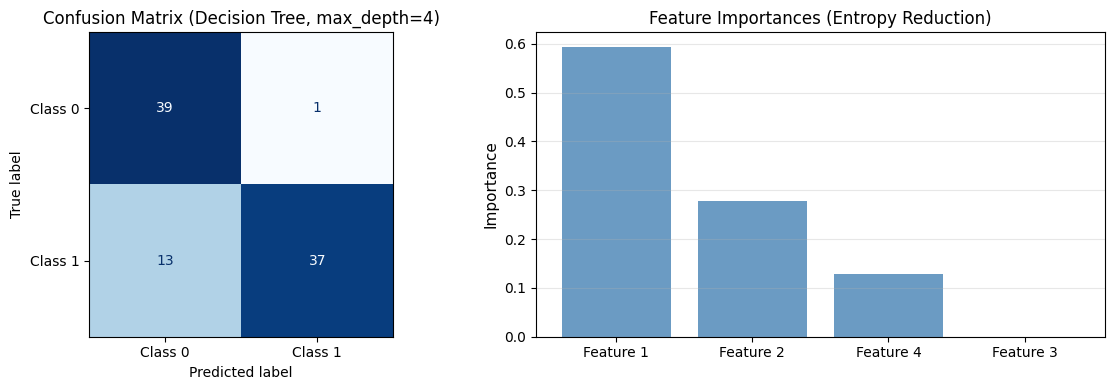

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

# ── Synthetic binary classification dataset ───────────────────────────────────
np.random.seed(42)
X_cls, y_cls = make_classification(n_samples=300, n_features=4, n_informative=3,
                                    n_redundant=1, random_state=42)
X_train, X_test_cls, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.3, random_state=42)

# ── Train ─────────────────────────────────────────────────────────────────────
clf_eval = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf_eval.fit(X_train, y_train)
y_pred_eval = clf_eval.predict(X_test_cls)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred_eval)
prec = precision_score(y_test, y_pred_eval)
rec  = recall_score(y_test, y_pred_eval)
f1   = f1_score(y_test, y_pred_eval)

print('=' * 45)
print(f"  {'Metric':<20} {'Value':>10}")
print('=' * 45)
for name, val in [('Accuracy', acc), ('Precision', prec), ('Recall', rec), ('F1 Score', f1)]:
    print(f"  {name:<20} {val:>10.4f}")
print('=' * 45)

# ── Confusion Matrix & Feature Importances ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred_eval)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Decision Tree, max_depth=4)', fontsize=12)

importances = clf_eval.feature_importances_
feat_names = [f'Feature {i+1}' for i in range(X_cls.shape[1])]
indices = np.argsort(importances)[::-1]
axes[1].bar(range(len(importances)), importances[indices], color='steelblue', alpha=0.8)
axes[1].set_xticks(range(len(importances)))
axes[1].set_xticklabels([feat_names[i] for i in indices], fontsize=10)
axes[1].set_title('Feature Importances (Entropy Reduction)', fontsize=12)
axes[1].set_ylabel('Importance', fontsize=11)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


<a name="section_3_5"></a>
### 3.5 Matplotlib Implementation of Trees A and B

Below is the code that generates the detailed visualizations of **Decision Tree A** and **Decision Tree B** discussed in [Section 1.3a](#section_1_3_trees).

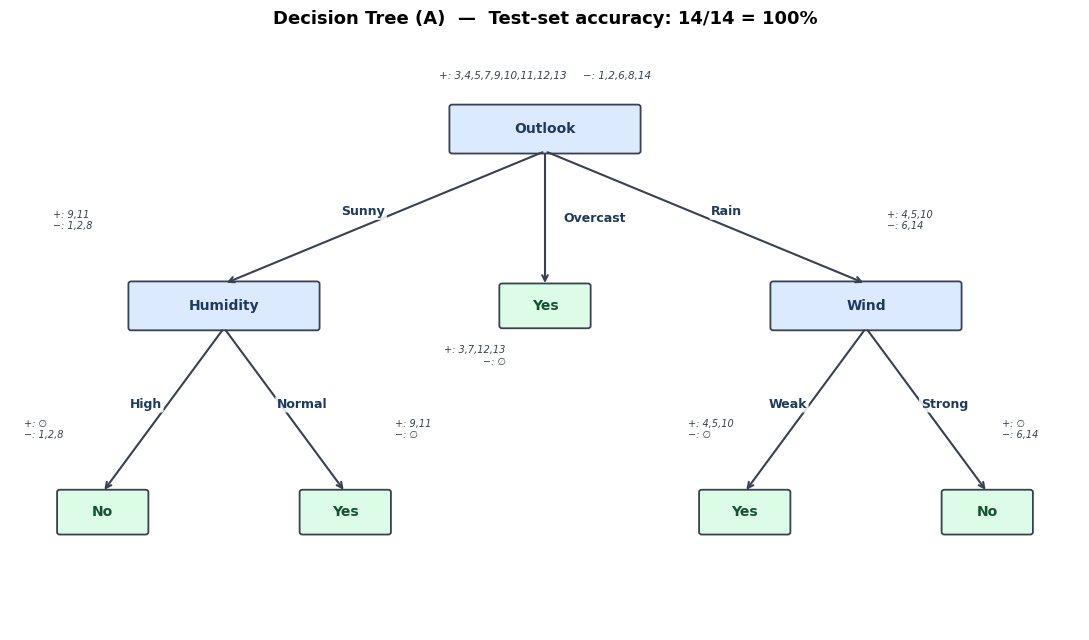

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ── Shared drawing helpers ────────────────────────────────────────────────────
def draw_box(ax, x, y, w, h, text, style='decision', fontsize=10):
    colors = {'decision': ('#dbeafe', '#1e3a5f'),
              'leaf':     ('#dcfce7', '#14532d'),
              'unknown':  ('#fff7ed', '#7c2d12')}
    fc, tc = colors.get(style, colors['decision'])
    box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle='round,pad=0.04',
                          facecolor=fc, edgecolor='#374151', linewidth=1.3)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=tc)

def draw_arrow(ax, x0, y0, x1, y1):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='#374151',
                                lw=1.5, connectionstyle='arc3,rad=0'))

def edge_label(ax, x0, y0, x1, y1, label, ox=0, oy=0, fs=9):
    ax.text((x0+x1)/2+ox, (y0+y1)/2+oy, label,
            ha='center', va='center', fontsize=fs, fontweight='bold', color='#1e3a5f',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.85))

def cnt(ax, x, y, txt, ha='left', fs=7):
    ax.text(x, y, txt, ha=ha, va='center', fontsize=fs, color='#374151', style='italic')

# ── Decision Tree (A): Outlook as root ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.set_xlim(-7.5, 7.5)
ax.set_ylim(-8.5, 1.5)
ax.axis('off')
W, H, LW, LH = 2.6, 0.75, 1.2, 0.68

# Nodes
draw_box(ax,  0.0,  0.0, W,  H,  'Outlook',  'decision')
draw_box(ax, -4.5, -3.0, W,  H,  'Humidity', 'decision')
draw_box(ax,  0.0, -3.0, LW, LH, 'Yes',      'leaf')
draw_box(ax,  4.5, -3.0, W,  H,  'Wind',     'decision')
draw_box(ax, -6.2, -6.5, LW, LH, 'No',       'leaf')
draw_box(ax, -2.8, -6.5, LW, LH, 'Yes',      'leaf')
draw_box(ax,  2.8, -6.5, LW, LH, 'Yes',      'leaf')
draw_box(ax,  6.2, -6.5, LW, LH, 'No',       'leaf')

# Arrows
for (x0,y0,x1,y1) in [
    (0,-H/2,   -4.5,-3.0+H/2),
    (0,-H/2,    0.0,-3.0+LH/2),
    (0,-H/2,    4.5,-3.0+H/2),
    (-4.5,-3.0-H/2, -6.2,-6.5+LH/2),
    (-4.5,-3.0-H/2, -2.8,-6.5+LH/2),
    ( 4.5,-3.0-H/2,  2.8,-6.5+LH/2),
    ( 4.5,-3.0-H/2,  6.2,-6.5+LH/2),
]:
    draw_arrow(ax, x0, y0, x1, y1)

# Edge labels
edge_label(ax,  0,-H/2,  -4.5,-3.0+H/2,  'Sunny',   -0.3, 0.1)
edge_label(ax,  0,-H/2,   0.0,-3.0+LH/2, 'Overcast',  0.7, 0.0)
edge_label(ax,  0,-H/2,   4.5,-3.0+H/2,  'Rain',      0.3, 0.1)
edge_label(ax, -4.5,-3.0-H/2, -6.2,-6.5+LH/2, 'High',   -0.25, 0.1)
edge_label(ax, -4.5,-3.0-H/2, -2.8,-6.5+LH/2, 'Normal',  0.25, 0.1)
edge_label(ax,  4.5,-3.0-H/2,  2.8,-6.5+LH/2, 'Weak',   -0.25, 0.1)
edge_label(ax,  4.5,-3.0-H/2,  6.2,-6.5+LH/2, 'Strong',  0.25, 0.1)

# Sample counts
ax.text(0, 0.85, '+: 3,4,5,7,9,10,11,12,13     −: 1,2,6,8,14',
        ha='center', fontsize=7.5, style='italic', color='#374151')
cnt(ax, -6.9, -1.55, '+: 9,11\n−: 1,2,8',     'left')
cnt(ax, -0.55,-3.85, '+: 3,7,12,13\n−: ∅', 'right', 7)
cnt(ax,  4.8, -1.55, '+: 4,5,10\n−: 6,14',    'left')
cnt(ax, -7.3, -5.1,  '+: ∅\n−: 1,2,8',       'left')
cnt(ax, -2.1, -5.1,  '+: 9,11\n−: ∅',         'left')
cnt(ax,  2.0, -5.1,  '+: 4,5,10\n−: ∅',       'left')
cnt(ax,  6.4, -5.1,  '+: ∅\n−: 6,14',         'left')

ax.set_title('Decision Tree (A)  —  Test-set accuracy: 14/14 = 100%',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


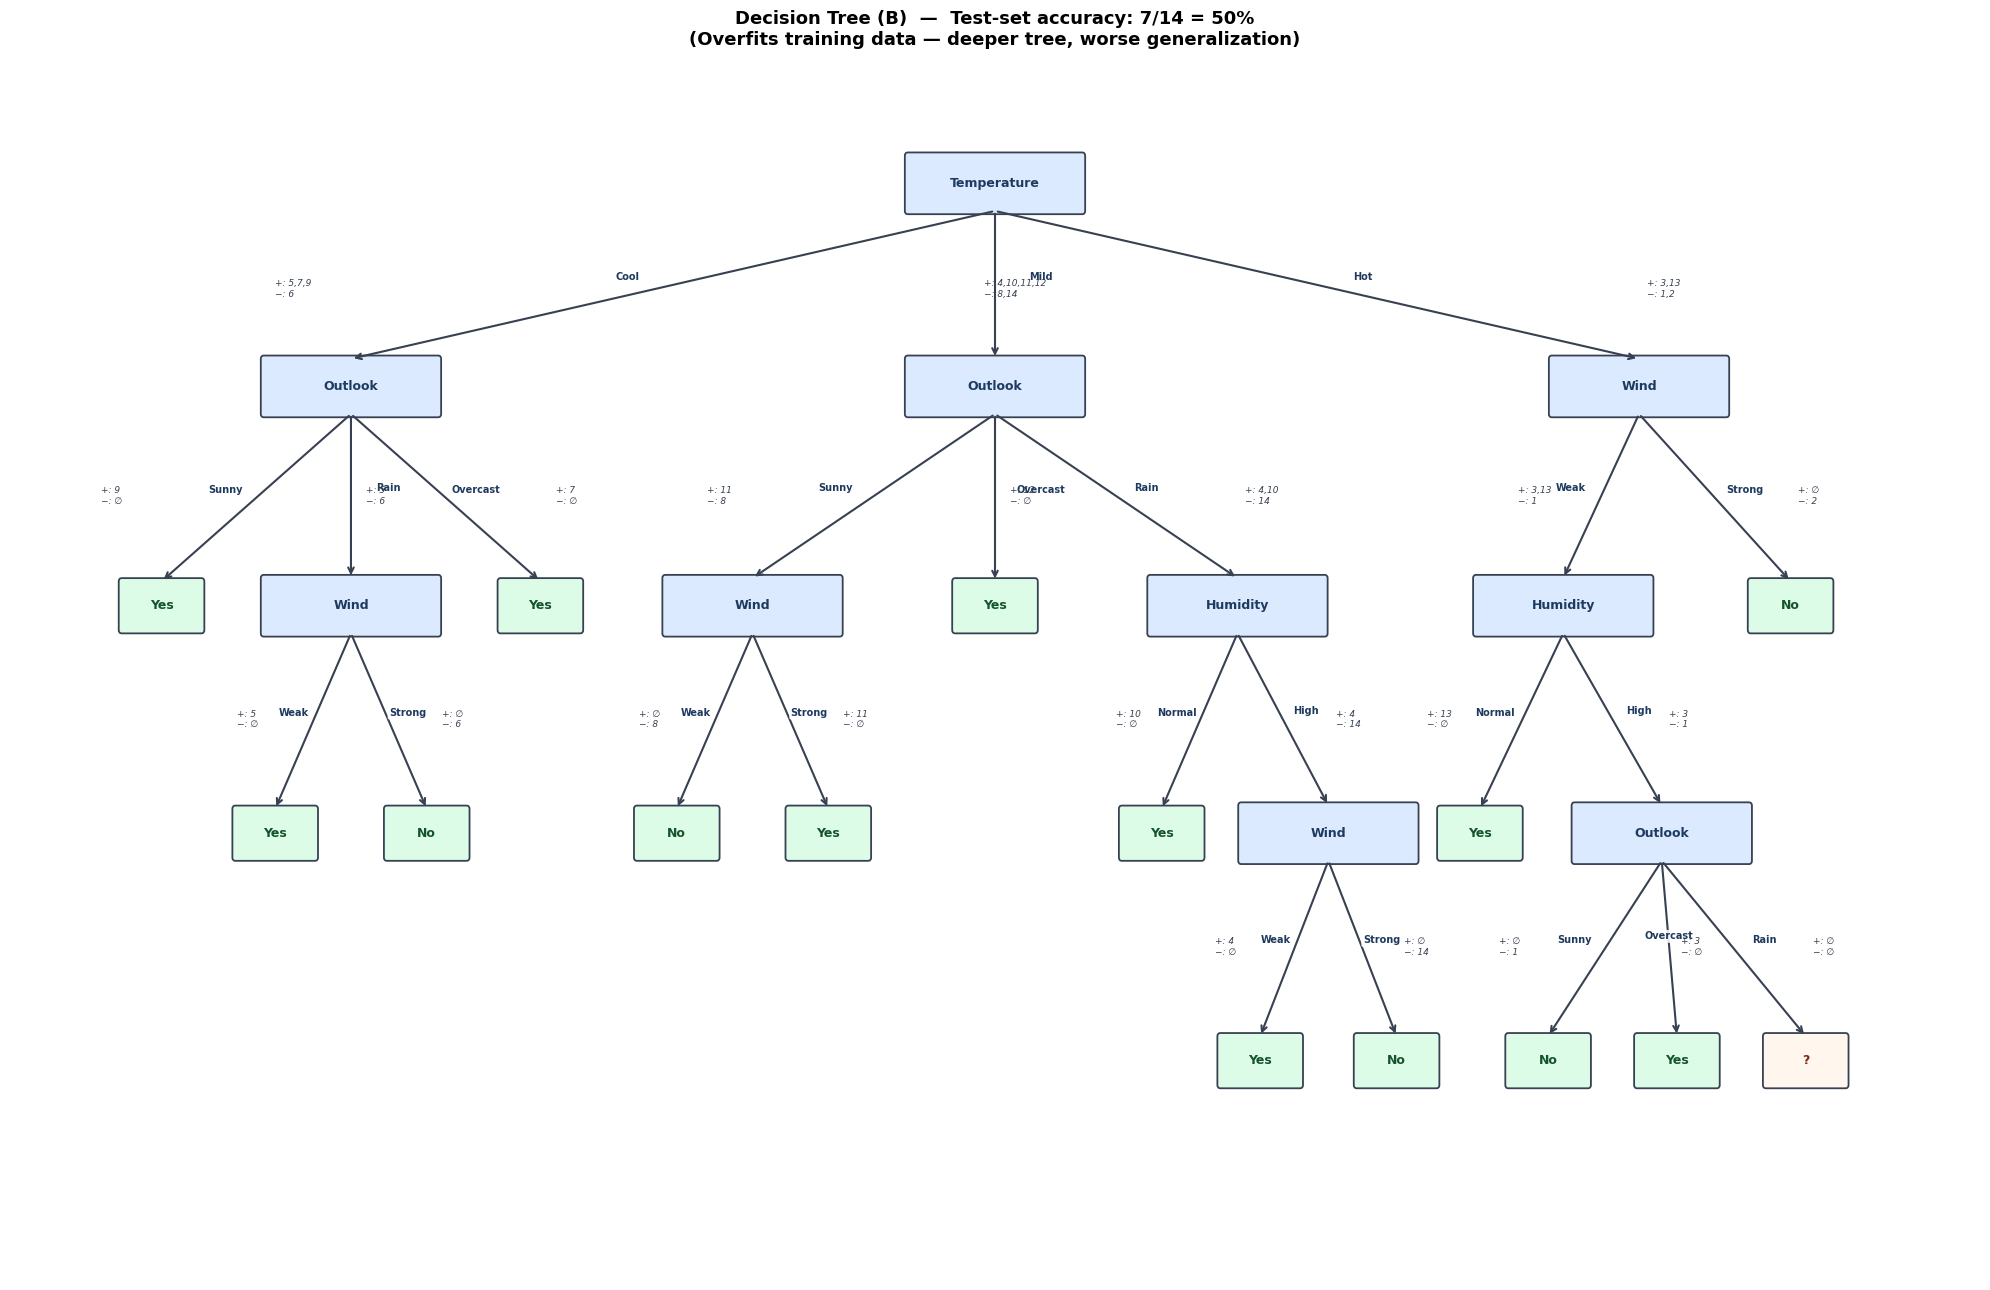

In [7]:
# ── Decision Tree (B): Temperature as root (more complex, overfits) ──────────
# (draw_box, draw_arrow, edge_label, cnt helpers defined in the previous cell)

fig2, ax2 = plt.subplots(figsize=(20, 13))
ax2.set_xlim(-13, 13)
ax2.set_ylim(-13.5, 1.5)
ax2.axis('off')

DW, DH, LW2, LH2 = 2.3, 0.68, 1.05, 0.6
fs, fss = 9, 6.5

def db(x,y,t,s='decision'): draw_box(ax2,x,y,DW,DH,t,s,fs)
def lb(x,y,t,s='leaf'):     draw_box(ax2,x,y,LW2,LH2,t,s,fs)
def ar(x0,y0,x1,y1):        draw_arrow(ax2,x0,y0,x1,y1)
def el(x0,y0,x1,y1,t,ox=0,oy=0): edge_label(ax2,x0,y0,x1,y1,t,ox,oy,fss+0.5)
def ct(x,y,t,ha='left'):    cnt(ax2,x,y,t,ha,fss)

# Root
db(0, 0, 'Temperature')

# Level 1
db(-8.5,-2.5,'Outlook'); db(0,-2.5,'Outlook'); db(8.5,-2.5,'Wind')
ar(0,-DH/2, -8.5,-2.5+DH/2); ar(0,-DH/2, 0,-2.5+DH/2); ar(0,-DH/2, 8.5,-2.5+DH/2)
el(0,-DH/2,-8.5,-2.5+DH/2,'Cool',-0.6,0.1)
el(0,-DH/2, 0,  -2.5+DH/2,'Mild', 0.6,0.1)
el(0,-DH/2, 8.5,-2.5+DH/2,'Hot',  0.6,0.1)
ct(-9.5,-1.3,'+: 5,7,9\n−: 6')
ct(-0.15,-1.3,'+: 4,10,11,12\n−: 8,14')
ct(8.6,-1.3,'+: 3,13\n−: 1,2')

# Cool subtree: Outlook -> Sunny/Rain(Wind)/Overcast
lb(-11.0,-5.2,'Yes'); db(-8.5,-5.2,'Wind'); lb(-6.0,-5.2,'Yes')
ar(-8.5,-2.5-DH/2,-11.0,-5.2+LH2/2)
ar(-8.5,-2.5-DH/2,-8.5,-5.2+DH/2)
ar(-8.5,-2.5-DH/2,-6.0,-5.2+LH2/2)
el(-8.5,-2.5-DH/2,-11.0,-5.2+LH2/2,'Sunny',   -0.4,0.1)
el(-8.5,-2.5-DH/2,-8.5, -5.2+DH/2, 'Rain',     0.5,0.1)
el(-8.5,-2.5-DH/2,-6.0, -5.2+LH2/2,'Overcast', 0.4,0.1)
ct(-11.8,-3.85,'+: 9\n−: ∅')
ct(-8.3, -3.85,'+: 5\n−: 6')
ct(-5.8, -3.85,'+: 7\n−: ∅')
lb(-9.5,-8.0,'Yes'); lb(-7.5,-8.0,'No')
ar(-8.5,-5.2-DH/2,-9.5,-8.0+LH2/2); ar(-8.5,-5.2-DH/2,-7.5,-8.0+LH2/2)
el(-8.5,-5.2-DH/2,-9.5,-8.0+LH2/2,'Weak',  -0.25,0.1)
el(-8.5,-5.2-DH/2,-7.5,-8.0+LH2/2,'Strong', 0.25,0.1)
ct(-10.0,-6.6,'+: 5\n−: ∅'); ct(-7.3,-6.6,'+: ∅\n−: 6')

# Mild subtree: Outlook -> Sunny(Wind)/Overcast/Rain(Humidity)
db(-3.2,-5.2,'Wind'); lb(0,-5.2,'Yes'); db(3.2,-5.2,'Humidity')
ar(0,-2.5-DH/2,-3.2,-5.2+DH/2); ar(0,-2.5-DH/2,0,-5.2+LH2/2); ar(0,-2.5-DH/2,3.2,-5.2+DH/2)
el(0,-2.5-DH/2,-3.2,-5.2+DH/2,  'Sunny',   -0.5,0.1)
el(0,-2.5-DH/2, 0,  -5.2+LH2/2, 'Overcast', 0.6,0.1)
el(0,-2.5-DH/2, 3.2,-5.2+DH/2,  'Rain',     0.4,0.1)
ct(-3.8,-3.85,'+: 11\n−: 8'); ct(0.2,-3.85,'+: 12\n−: ∅'); ct(3.3,-3.85,'+: 4,10\n−: 14')
lb(-4.2,-8.0,'No'); lb(-2.2,-8.0,'Yes')
ar(-3.2,-5.2-DH/2,-4.2,-8.0+LH2/2); ar(-3.2,-5.2-DH/2,-2.2,-8.0+LH2/2)
el(-3.2,-5.2-DH/2,-4.2,-8.0+LH2/2,'Weak',  -0.25,0.1)
el(-3.2,-5.2-DH/2,-2.2,-8.0+LH2/2,'Strong', 0.25,0.1)
ct(-4.7,-6.6,'+: ∅\n−: 8'); ct(-2.0,-6.6,'+: 11\n−: ∅')
lb(2.2,-8.0,'Yes'); db(4.4,-8.0,'Wind')
ar(3.2,-5.2-DH/2,2.2,-8.0+LH2/2); ar(3.2,-5.2-DH/2,4.4,-8.0+DH/2)
el(3.2,-5.2-DH/2,2.2,-8.0+LH2/2,'Normal',-0.3,0.1)
el(3.2,-5.2-DH/2,4.4,-8.0+DH/2, 'High',   0.3,0.1)
ct(1.6,-6.6,'+: 10\n−: ∅'); ct(4.5,-6.6,'+: 4\n−: 14')
lb(3.5,-10.8,'Yes'); lb(5.3,-10.8,'No')
ar(4.4,-8.0-DH/2,3.5,-10.8+LH2/2); ar(4.4,-8.0-DH/2,5.3,-10.8+LH2/2)
el(4.4,-8.0-DH/2,3.5,-10.8+LH2/2,'Weak',  -0.25,0.1)
el(4.4,-8.0-DH/2,5.3,-10.8+LH2/2,'Strong', 0.25,0.1)
ct(2.9,-9.4,'+: 4\n−: ∅'); ct(5.4,-9.4,'+: ∅\n−: 14')

# Hot subtree: Wind -> Weak(Humidity)/Strong
db(7.5,-5.2,'Humidity'); lb(10.5,-5.2,'No')
ar(8.5,-2.5-DH/2,7.5,-5.2+DH/2); ar(8.5,-2.5-DH/2,10.5,-5.2+LH2/2)
el(8.5,-2.5-DH/2, 7.5,-5.2+DH/2, 'Weak',  -0.4,0.1)
el(8.5,-2.5-DH/2,10.5,-5.2+LH2/2,'Strong',  0.4,0.1)
ct(6.9,-3.85,'+: 3,13\n−: 1'); ct(10.6,-3.85,'+: ∅\n−: 2')
lb(6.4,-8.0,'Yes'); db(8.8,-8.0,'Outlook')
ar(7.5,-5.2-DH/2,6.4,-8.0+LH2/2); ar(7.5,-5.2-DH/2,8.8,-8.0+DH/2)
el(7.5,-5.2-DH/2,6.4,-8.0+LH2/2,'Normal',-0.35,0.1)
el(7.5,-5.2-DH/2,8.8,-8.0+DH/2, 'High',   0.35,0.1)
ct(5.7,-6.6,'+: 13\n−: ∅'); ct(8.9,-6.6,'+: 3\n−: 1')
lb(7.3,-10.8,'No'); lb(9.0,-10.8,'Yes'); lb(10.7,-10.8,'?','unknown')
ar(8.8,-8.0-DH/2,7.3,-10.8+LH2/2)
ar(8.8,-8.0-DH/2,9.0,-10.8+LH2/2)
ar(8.8,-8.0-DH/2,10.7,-10.8+LH2/2)
el(8.8,-8.0-DH/2, 7.3,-10.8+LH2/2,'Sunny',   -0.4,0.1)
el(8.8,-8.0-DH/2, 9.0,-10.8+LH2/2,'Overcast',  0.0,0.15)
el(8.8,-8.0-DH/2,10.7,-10.8+LH2/2,'Rain',      0.4,0.1)
ct(6.65,-9.4,'+: ∅\n−: 1'); ct(9.05,-9.4,'+: 3\n−: ∅'); ct(10.8,-9.4,'+: ∅\n−: ∅')

ax2.set_title('Decision Tree (B)  —  Test-set accuracy: 7/14 = 50%\n'
              '(Overfits training data — deeper tree, worse generalization)',
              fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


<a name="part_4"></a>
# Part 4: Code for Advanced Decision Trees

This section implements decision trees and gradient boosting **from scratch** using NumPy, providing a deeper understanding of the underlying mechanics.

---

<a name="section_4_1"></a>
### 4.1 Implementing ID3 from Scratch

We implement the ID3 algorithm (entropy + information gain) from scratch for categorical features, reproducing the Jeeves example from Part 1.


In [8]:
import numpy as np
import pandas as pd
from collections import Counter

# ── Helper functions ──────────────────────────────────────────────────────────

def entropy(labels):
    if len(labels) == 0:
        return 0.0
    counts = Counter(labels)
    total = len(labels)
    return -sum((c / total) * np.log2(c / total) for c in counts.values() if c > 0)

def information_gain(data, feature, target):
    total_entropy = entropy(data[target].tolist())
    values = data[feature].unique()
    weighted = sum(
        (len(subset) / len(data)) * entropy(subset[target].tolist())
        for v in values
        for subset in [data[data[feature] == v]]
    )
    return total_entropy - weighted

def majority_class(labels):
    if len(labels) == 0:
        return None
    return Counter(labels).most_common(1)[0][0]

# ── Node class ────────────────────────────────────────────────────────────────

class TreeNode:
    def __init__(self):
        self.feature = None
        self.branches = {}
        self.label = None
        self.is_leaf = False

# ── ID3 Decision Tree class ───────────────────────────────────────────────────

class ID3DecisionTree:
    def __init__(self):
        self.root = None
        self.target = None

    def fit(self, data, target, features=None):
        self.target = target
        if features is None:
            features = [c for c in data.columns if c != target]
        self.root = self._build(data, features, majority_class(data[target].tolist()))
        return self

    def _build(self, data, features, parent_majority):
        node = TreeNode()
        labels = data[self.target].tolist()

        if len(set(labels)) == 1:
            node.is_leaf, node.label = True, labels[0]
            return node
        if len(features) == 0:
            node.is_leaf, node.label = True, majority_class(labels)
            return node
        if len(data) == 0:
            node.is_leaf, node.label = True, parent_majority
            return node

        # Choose best feature
        gains = {f: information_gain(data, f, self.target) for f in features}
        best = max(gains, key=gains.get)
        node.feature = best

        parent_maj = majority_class(labels)
        remaining = [f for f in features if f != best]

        for val in data[best].unique():
            subset = data[data[best] == val]
            node.branches[val] = self._build(subset, remaining, parent_maj)

        return node

    def predict_one(self, sample):
        node = self.root
        while not node.is_leaf:
            val = sample.get(node.feature)
            if val not in node.branches:
                return list(node.branches.values())[0].label
            node = node.branches[val]
        return node.label

    def predict(self, df):
        return [self.predict_one(row) for row in df.to_dict(orient='records')]

    def print_tree(self, node=None, indent=0, branch_label='ROOT'):
        if node is None:
            node = self.root
        prefix = '    ' * indent
        if node.is_leaf:
            print(f'{prefix}[{branch_label}] -> PREDICT: {node.label}')
        else:
            print(f'{prefix}[{branch_label}] -> TEST: {node.feature}')
            for val, child in node.branches.items():
                self.print_tree(child, indent + 1, f'{node.feature}={val}')

# ── Run on Play Tennis Dataset ────────────────────────────────────────────────

data = pd.DataFrame({
    'Outlook':  ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
                 'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temp':     ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                 'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal',
                 'High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':     ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
                 'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis':['No','No','Yes','Yes','Yes','No','Yes',
                  'No','Yes','Yes','Yes','Yes','Yes','No']
})

tree = ID3DecisionTree()
tree.fit(data, target='PlayTennis')

print('=== ID3 Decision Tree (From Scratch) ===\n')
tree.print_tree()

predictions = tree.predict(data)
acc = sum(p == t for p, t in zip(predictions, data['PlayTennis'])) / len(data)
print(f'\nTraining Accuracy: {acc:.4f}')

# Test on new examples
print('\n=== Predictions on New Examples ===')
test_cases = [
    {'Outlook': 'Sunny',    'Temp': 'Mild', 'Humidity': 'Normal', 'Wind': 'Weak'},
    {'Outlook': 'Overcast', 'Temp': 'Hot',  'Humidity': 'High',   'Wind': 'Strong'},
    {'Outlook': 'Rain',     'Temp': 'Mild', 'Humidity': 'High',   'Wind': 'Strong'},
]
for tc in test_cases:
    print(f'  {tc} -> {tree.predict_one(tc)}')


=== ID3 Decision Tree (From Scratch) ===

[ROOT] -> TEST: Outlook
    [Outlook=Sunny] -> TEST: Humidity
        [Humidity=High] -> PREDICT: No
        [Humidity=Normal] -> PREDICT: Yes
    [Outlook=Overcast] -> PREDICT: Yes
    [Outlook=Rain] -> TEST: Wind
        [Wind=Weak] -> PREDICT: Yes
        [Wind=Strong] -> PREDICT: No

Training Accuracy: 1.0000

=== Predictions on New Examples ===
  {'Outlook': 'Sunny', 'Temp': 'Mild', 'Humidity': 'Normal', 'Wind': 'Weak'} -> Yes
  {'Outlook': 'Overcast', 'Temp': 'Hot', 'Humidity': 'High', 'Wind': 'Strong'} -> Yes
  {'Outlook': 'Rain', 'Temp': 'Mild', 'Humidity': 'High', 'Wind': 'Strong'} -> No


<a name="section_4_2"></a>
### 4.2 Gradient Boosting from Scratch (MSE Loss)

We implement a **Gradient Boosting Regressor** from scratch using NumPy and shallow decision trees as base learners. Each new tree is fitted to the **pseudo-residuals** (negative gradient of MSE) of the current ensemble — implementing Equations (2.8)–(2.10) from Part 2.


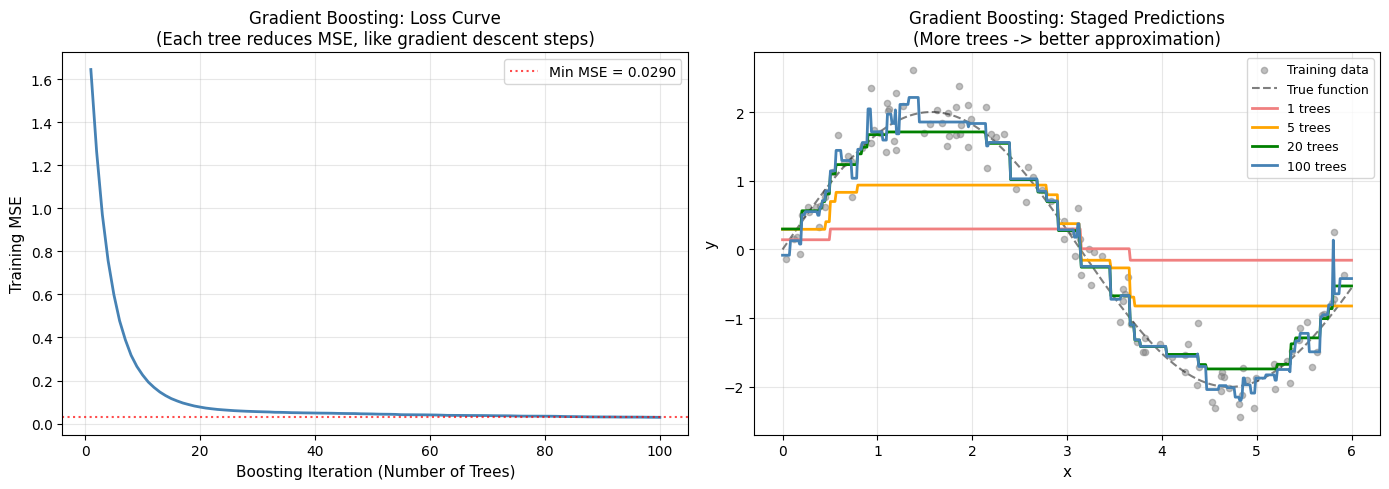

Initial prediction F0 (mean of y): 0.0905
Final Training MSE (100 trees):    0.029016


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

class GradientBoostingRegressorScratch:

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate  # eta (Eq. 2.10)
        self.max_depth = max_depth
        self.trees = []
        self.F0 = None

    def fit(self, X, y):
        # Step 1: Initialize F0 with mean (minimizes MSE, Eq. 2.8)
        self.F0 = np.mean(y)
        F = np.full(len(y), self.F0)
        self.train_losses = []

        for t in range(self.n_estimators):
            # Step 2a: Pseudo-residuals = negative gradient of MSE (Eq. 2.9)
            # For MSE: d/dF [0.5*(y-F)^2] = -(y-F)  =>  r = y - F
            residuals = y - F

            # Step 2b: Fit a regression tree to the pseudo-residuals
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=t)
            tree.fit(X, residuals)
            self.trees.append(tree)

            # Step 2c: Update the ensemble (Eq. 2.10)
            F = F + self.learning_rate * tree.predict(X)

            self.train_losses.append(np.mean((y - F) ** 2))

        return self

    def predict(self, X):
        F = np.full(X.shape[0], self.F0)
        for tree in self.trees:
            F = F + self.learning_rate * tree.predict(X)
        return F

    def staged_predict(self, X):
        F = np.full(X.shape[0], self.F0)
        yield F.copy()
        for tree in self.trees:
            F = F + self.learning_rate * tree.predict(X)
            yield F.copy()

# ── Train on nonlinear 1D data ────────────────────────────────────────────────
np.random.seed(42)
X_gb = np.sort(np.random.uniform(0, 6, 120)).reshape(-1, 1)
y_gb = np.sin(X_gb.ravel()) * 2 + np.random.normal(0, 0.3, 120)

gb = GradientBoostingRegressorScratch(n_estimators=100, learning_rate=0.15, max_depth=2)
gb.fit(X_gb, y_gb)

# ── Visualize results ─────────────────────────────────────────────────────────
X_plot = np.linspace(0, 6, 500).reshape(-1, 1)
all_preds = list(gb.staged_predict(X_plot))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(range(1, len(gb.train_losses)+1), gb.train_losses,
             color='steelblue', linewidth=2)
axes[0].set_xlabel('Boosting Iteration (Number of Trees)', fontsize=11)
axes[0].set_ylabel('Training MSE', fontsize=11)
axes[0].set_title('Gradient Boosting: Loss Curve\n'
                  '(Each tree reduces MSE, like gradient descent steps)', fontsize=12)
axes[0].axhline(min(gb.train_losses), color='red', linestyle=':', alpha=0.7,
                 label=f'Min MSE = {min(gb.train_losses):.4f}')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Staged predictions
stages = [1, 5, 20, 100]
colors = ['lightcoral', 'orange', 'green', 'steelblue']
axes[1].scatter(X_gb, y_gb, s=20, alpha=0.5, color='gray', label='Training data')
axes[1].plot(X_plot, np.sin(X_plot.ravel())*2, 'k--', linewidth=1.5,
             alpha=0.5, label='True function')
for n, col in zip(stages, colors):
    axes[1].plot(X_plot, all_preds[n], color=col, linewidth=2, label=f'{n} trees')
axes[1].set_title('Gradient Boosting: Staged Predictions\n'
                  '(More trees -> better approximation)', fontsize=12)
axes[1].set_xlabel('x', fontsize=11)
axes[1].set_ylabel('y', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Initial prediction F0 (mean of y): {gb.F0:.4f}')
print(f'Final Training MSE (100 trees):    {gb.train_losses[-1]:.6f}')


<a name="section_4_3"></a>
### 4.3 AI Problem-Solving with Decision Trees: Student Exam Prediction

We apply a decision tree to the AI problem of predicting student exam outcomes. This demonstrates: **(a)** the decision tree as a rational agent's policy, **(b)** cross-validation for model selection, and **(c)** feature importance as an interpretability tool.


Student Performance Dataset (first 8 rows):
 Hours_Study  Attendance  Prev_GPA  Sleep_Hours  Pass
        5.12       52.58      2.34         5.04     0
       11.46       76.57      2.56         4.13     1
        9.05       77.03      2.35         4.91     0
        7.59       81.87      2.18         6.92     1
        2.72       86.30      2.24         6.11     0
        2.72       98.79      2.92         8.46     0
        1.64       75.82      2.41         8.09     0
       10.53       66.15      2.73         5.71     1

Total samples: 300   Pass rate: 53.3%


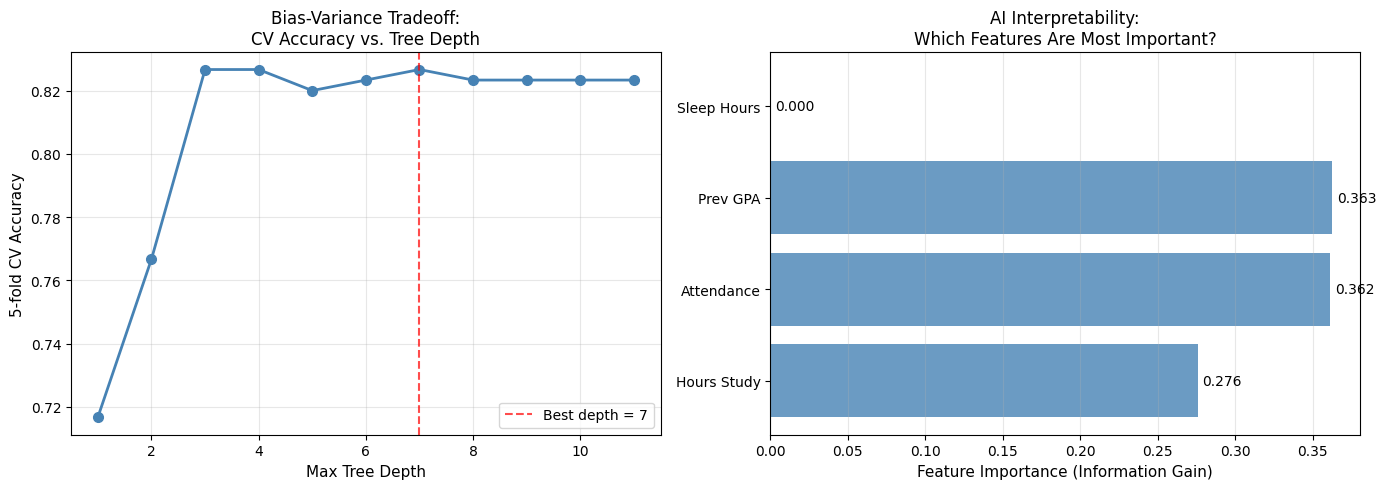

Best CV depth: 7  |  Best CV Accuracy: 0.8267

Feature Importances (depth-3 tree):
  Prev GPA             0.3626
  Attendance           0.3615
  Hours Study          0.2759
  Sleep Hours          0.0000


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score

# ── Synthetic Student Dataset ─────────────────────────────────────────────────
np.random.seed(42)
n = 300
hours_study = np.random.uniform(1, 12, n)
attendance  = np.random.uniform(50, 100, n)
prev_gpa    = np.random.uniform(2.0, 4.0, n)
sleep_hrs   = np.random.uniform(4, 9, n)

# Ground-truth decision rule (what an ideal rational agent would learn)
score = (0.35 * hours_study / 12 +
         0.25 * (attendance - 50) / 50 +
         0.30 * (prev_gpa - 2.0) / 2.0 +
         0.10 * (sleep_hrs - 4) / 5)
pass_label = (score + np.random.normal(0, 0.05, n) > 0.5).astype(int)

df_st = pd.DataFrame({
    'Hours_Study': hours_study,
    'Attendance':  attendance,
    'Prev_GPA':    prev_gpa,
    'Sleep_Hours': sleep_hrs,
    'Pass':        pass_label
})

print('Student Performance Dataset (first 8 rows):')
print(df_st.head(8).round(2).to_string(index=False))
print(f'\nTotal samples: {n}   Pass rate: {pass_label.mean():.1%}')

X_st = df_st[['Hours_Study', 'Attendance', 'Prev_GPA', 'Sleep_Hours']].values
y_st = df_st['Pass'].values
feature_names = ['Hours Study', 'Attendance', 'Prev GPA', 'Sleep Hours']

# ── Cross-validated accuracy for different depths ─────────────────────────────
depths = range(1, 12)
cv_scores = []
for d in depths:
    clf_d = DecisionTreeClassifier(max_depth=d, criterion='entropy', random_state=42)
    scores = cross_val_score(clf_d, X_st, y_st, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_depth = list(depths)[np.argmax(cv_scores)]

# ── Final interpretable tree (max_depth=3) ───────────────────────────────────
clf_final = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
clf_final.fit(X_st, y_st)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cross-validation curve
axes[0].plot(list(depths), cv_scores, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(best_depth, color='red', linestyle='--', alpha=0.7,
                 label=f'Best depth = {best_depth}')
axes[0].set_xlabel('Max Tree Depth', fontsize=11)
axes[0].set_ylabel('5-fold CV Accuracy', fontsize=11)
axes[0].set_title('Bias-Variance Tradeoff:\nCV Accuracy vs. Tree Depth', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Feature importances
importances = clf_final.feature_importances_
bars = axes[1].barh(feature_names, importances, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Feature Importance (Information Gain)', fontsize=11)
axes[1].set_title('AI Interpretability:\nWhich Features Are Most Important?', fontsize=12)
axes[1].grid(True, axis='x', alpha=0.3)
for bar, imp in zip(bars, importances):
    axes[1].text(imp + 0.003, bar.get_y() + bar.get_height()/2,
                  f'{imp:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'Best CV depth: {best_depth}  |  Best CV Accuracy: {max(cv_scores):.4f}')
print('\nFeature Importances (depth-3 tree):')
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f'  {name:<20} {imp:.4f}')


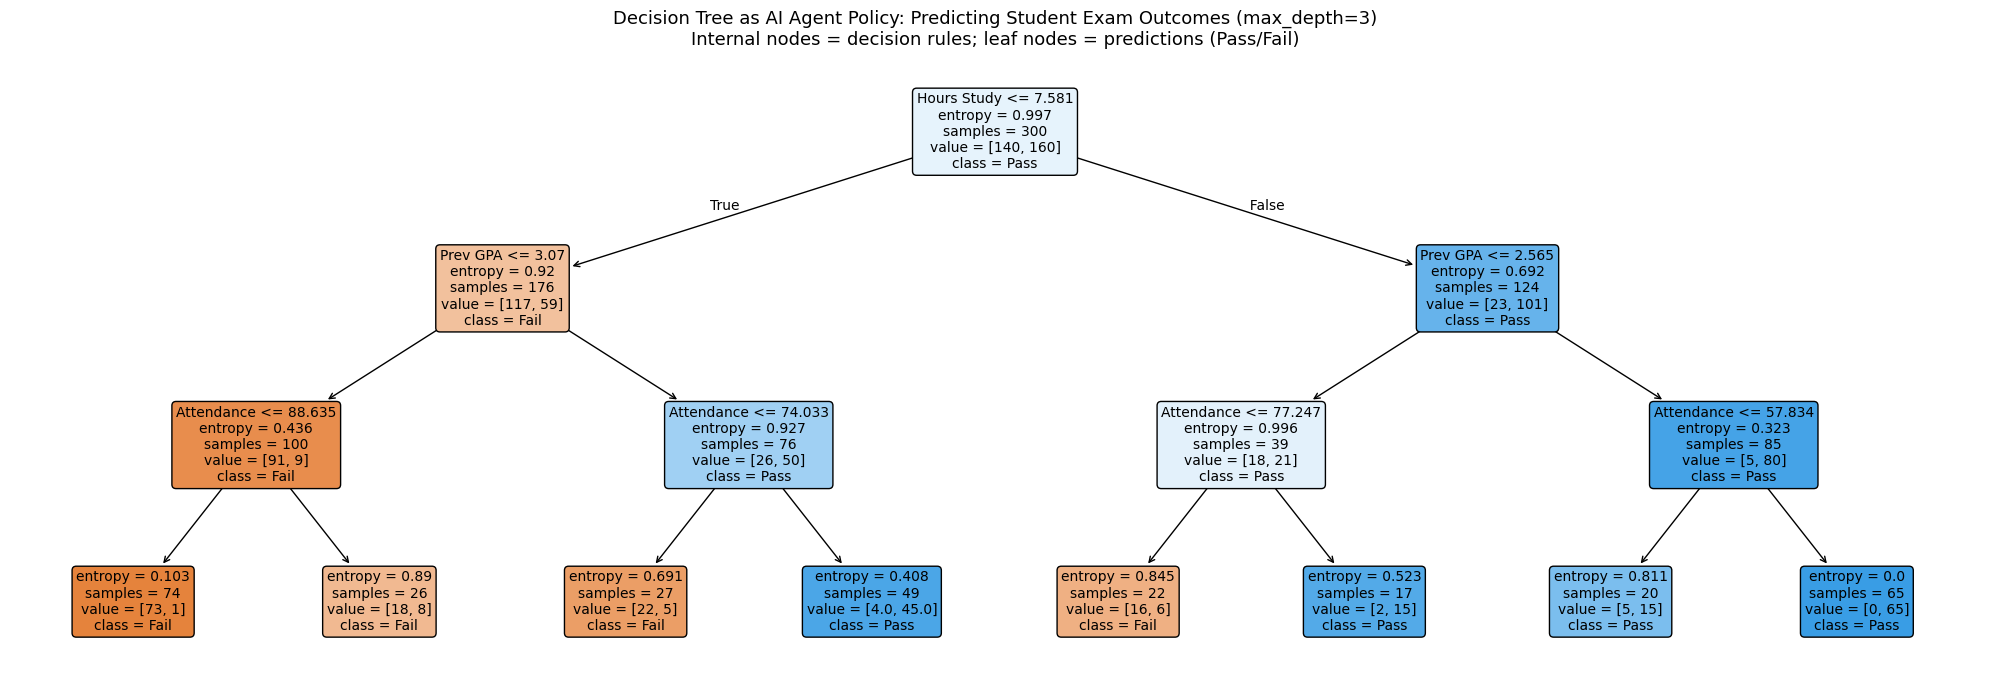


=== AI Agent: Predicting New Students ===
Student    Hours    Attend%    GPA     Sleep    Pred        P(Pass)
-----------------------------------------------------------------
  #1      2.0      60.0       2.2     5.0      FAIL         0.0135
  #2      9.5      93.0       3.8     7.5      PASS         1.0000
  #3      5.0      75.0       3.0     6.0      FAIL         0.0135
  #4      10.0     88.0       3.5     8.0      PASS         1.0000


In [11]:
# ── Visualize the interpretable AI agent policy (decision tree) ───────────────
fig, ax = plt.subplots(figsize=(20, 7))
plot_tree(
    clf_final,
    feature_names=feature_names,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(
    'Decision Tree as AI Agent Policy: Predicting Student Exam Outcomes (max_depth=3)\n'
    'Internal nodes = decision rules; leaf nodes = predictions (Pass/Fail)',
    fontsize=13
)
plt.tight_layout()
plt.show()

# ── Simulate AI agent making predictions ─────────────────────────────────────
print('\n=== AI Agent: Predicting New Students ===')
new_students = np.array([
    [2.0, 60.0, 2.2, 5.0],   # low study, low attendance
    [9.5, 93.0, 3.8, 7.5],   # high study, high attendance
    [5.0, 75.0, 3.0, 6.0],   # moderate everything
    [10.0, 88.0, 3.5, 8.0],  # very high study
])

preds = clf_final.predict(new_students)
probs = clf_final.predict_proba(new_students)

header = f"{'Student':<10} {'Hours':<8} {'Attend%':<10} {'GPA':<7} {'Sleep':<8} {'Pred':<10} {'P(Pass)':>8}"
print(header)
print('-' * 65)
for i, (row, pred, prob) in enumerate(zip(new_students, preds, probs)):
    label = 'PASS ' if pred == 1 else 'FAIL '
    print(f"  #{i+1:<6} {row[0]:<8.1f} {row[1]:<10.1f} {row[2]:<7.1f} {row[3]:<8.1f} {label:<10} {prob[1]:>8.4f}")


© 2026 Ghassem Tofighi. All rights reserved. Unauthorized reuse or distribution is prohibited.
